# 2 — Multi-hop retrieval and query decomposition

Single retrieval calls fetch what looks like the *whole question*, so on "compare X to Y" the top-k fixates on one half. The fix is to plan **sub-queries** and retrieve for each independently. We build a LangGraph workflow `plan → retrieve_each (fan-out via reducer) → aggregate → answer`, then compare different planner models against a fixed downstream pipeline to see whether quality tracks planner quality.

The `Annotated[list, operator.add]` reducer pattern for parallel-friendly state is the same one LangGraph's deep-research examples use.

In [1]:
import operator
import os
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()
assert os.environ.get("OPENROUTER_API_KEY")

from corpus import load_chroma, load_gold_set
from llm import get_llm, get_structured_llm

chroma = load_chroma()
gold = load_gold_set()
print(f"Corpus: {chroma._collection.count()} chunks, gold set: {len(gold)} questions")

/Users/sinanozdemir/Teaching/Pearson/advanced-agentic-ai-in-three-weeks/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8232.59it/s]


Corpus: 3689 chunks, gold set: 30 questions


## The query planner

An LLM call with structured output turns a complex question into N sub-queries. Pydantic + `with_structured_output` guarantees a list of strings back, not free-form text. A good planner emits sub-queries that are individually answerable, cover different facets, and use vocabulary the corpus likely contains (e.g. "BM25" rather than "sparse retrieval algorithm").

In [2]:
class QueryPlan(BaseModel):
    sub_queries: list[str] = Field(
        description=(
            "2-5 self-contained sub-queries that each retrieve evidence for a "
            "distinct facet of the user's question. Use vocabulary likely to "
            "appear in the corpus."
        ),
        min_length=2,
        max_length=5,
    )
    rationale: str = Field(description="One sentence explaining the decomposition.")


PLANNER_SYSTEM = (
    "You are a retrieval planner for a RAG system over a heterogeneous corpus "
    "(blog posts, encyclopedia articles, fact paragraphs). Given a user "
    "question, decompose it into 2-5 sub-queries whose evidence, taken "
    "together, would let a writer answer the question. Each sub-query must be "
    "self-contained (no pronouns referring to the original question)."
)


def plan_queries(question: str, model: str = "openai/gpt-5.4-nano") -> QueryPlan:
    planner = get_structured_llm(model, QueryPlan)
    return planner.invoke([
        SystemMessage(content=PLANNER_SYSTEM),
        HumanMessage(content=f"USER QUESTION:\n{question}"),
    ])


example_q = next(q for q in gold if q.id == "cross_02").question
plan = plan_queries(example_q)
print("Question:", example_q[:140], "...\n")
print("Rationale:", plan.rationale)
for i, sq in enumerate(plan.sub_queries, 1):
    print(f"  {i}. {sq}")

Question: Compare what the AI Office Hours '(Re-) Ranking RAG Solutions' post recommends to how Wikipedia describes BM25 and cross-encoders as informa ...

Rationale: Decompose the comparison by retrieving (1) what the AI Office Hours post recommends for reranking/RAG solutions and any stated retrieval method comparisons, and (2) Wikipedia’s descriptions of BM25 and cross-encoders as information retrieval techniques.
  1. AI Office Hours “(Re-) Ranking RAG Solutions” recommended approaches for reranking in retrieval-augmented generation, including what models or reranking strategies are suggested
  2. AI Office Hours “(Re-) Ranking RAG Solutions” discussion of BM25 or sparse retrieval and whether the post compares it to other retrieval methods
  3. Wikipedia description of BM25 as an information retrieval technique, including how BM25 scores relevance
  4. Wikipedia description of cross-encoders as an information retrieval technique, including how cross-encoder architectures operate fo

## The multi-hop graph

State carries `sub_queries` and an accumulating `evidence` list. We use `Annotated[list[Document], operator.add]` so multiple branches can append to evidence without overwriting each other — the same reducer pattern LangGraph uses for parallel-friendly state.

For simplicity in this notebook we run the sub-queries **sequentially** in one node. The fifth notebook will fan them out into parallel branches.

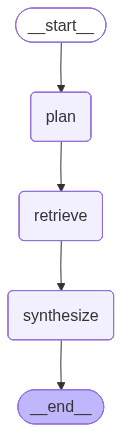

In [3]:
class MultiHopState(TypedDict):
    question: str
    sub_queries: list[str]
    plan_rationale: str
    evidence: Annotated[list[Document], operator.add]
    answer: str


SYNTH_SYSTEM = (
    "You are a careful technical writer. Answer the user's question using only "
    "the provided evidence. Cite the source of each claim inline like "
    "[wikipedia: Article Title] or [beehiiv: post slug]. If the evidence is "
    "insufficient for a part of the question, say so explicitly."
)


def make_multihop_graph(planner_model: str, synth_model: str, k_per_query: int = 3):
    def plan_node(state: MultiHopState) -> dict:
        plan = plan_queries(state["question"], model=planner_model)
        return {"sub_queries": plan.sub_queries, "plan_rationale": plan.rationale}

    def retrieve_node(state: MultiHopState) -> dict:
        evidence: list[Document] = []
        seen: set[str] = set()
        for sq in state["sub_queries"]:
            for d in chroma.similarity_search(sq, k=k_per_query):
                cid = d.metadata.get("chunk_id", id(d))
                if cid in seen:
                    continue
                seen.add(cid)
                evidence.append(d)
        return {"evidence": evidence}

    def synth_node(state: MultiHopState) -> dict:
        ctx = "\n\n---\n\n".join(
            f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:50]}] {d.page_content}"
            for d in state["evidence"]
        )
        msg = (
            f"USER QUESTION:\n{state['question']}\n\n"
            f"EVIDENCE:\n{ctx}\n\n"
            "Write a synthesized answer with inline citations."
        )
        ai = get_llm(synth_model).invoke([
            SystemMessage(content=SYNTH_SYSTEM),
            HumanMessage(content=msg),
        ])
        return {"answer": ai.content}

    g = StateGraph(MultiHopState)
    g.add_node("plan", plan_node)
    g.add_node("retrieve", retrieve_node)
    g.add_node("synthesize", synth_node)
    g.add_edge(START, "plan")
    g.add_edge("plan", "retrieve")
    g.add_edge("retrieve", "synthesize")
    g.add_edge("synthesize", END)
    return g.compile()


multihop = make_multihop_graph(planner_model="openai/gpt-5.4-nano", synth_model="anthropic/claude-opus-4.7")

try:
    from IPython.display import Image, display
    display(Image(multihop.get_graph().draw_mermaid_png()))
except Exception:
    print(multihop.get_graph().draw_ascii())

In [4]:
target = next(q for q in gold if q.id == "cross_02")
state_in = {
    "question": target.question,
    "sub_queries": [],
    "plan_rationale": "",
    "evidence": [],
    "answer": "",
}
result = multihop.invoke(state_in)

print("Sub-queries planned:")
for sq in result["sub_queries"]:
    print(f"  - {sq}")
print(f"\nEvidence chunks retrieved: {len(result['evidence'])}")
print("\n--- Multi-hop answer ---")
print(result["answer"])

Sub-queries planned:
  - AI Office Hours '(Re-) Ranking RAG Solutions' blog post recommendations for (re-)ranking in retrieval augmented generation, including any discussion of BM25 or cross-encoder usage
  - AI Office Hours '(Re-) Ranking RAG Solutions' post details about recommended RAG pipeline components: candidate retrieval stage and subsequent re-ranking stage
  - Wikipedia explanation of BM25 as an information retrieval technique: term frequency–inverse document frequency, ranking function, and typical use in search engines
  - Wikipedia description of cross-encoders as an information retrieval / reranking technique: how they score query-document pairs using joint encoding and attention
  - Wikipedia page(s) or sections comparing BM25 and neural rerankers/cross-encoders in retrieval contexts, including differences in scoring and computational cost

Evidence chunks retrieved: 11

--- Multi-hop answer ---
# Comparing AI Office Hours' Re-Ranking Recommendations with Wikipedia's Des

## The real test: does decomposition rescue a *weak* synthesizer?

A planner sweep with a frontier synthesizer doesn't prove much — Claude Opus is strong enough to fake answers from its priors even with a sloppy plan. To isolate the workflow's contribution we **fix the synth to cheap `gpt-5.4-nano`** (~25× cheaper than Opus) and ask: when the synth is too weak to confabulate, does decomposition close the gap?

| Approach | Planner | What it tests |
|---|---|---|
| `simple_rag` | none — single dense top-k | Baseline: weak synth, weak retrieval |
| `multihop` | `gpt-5.4-nano` | Workflow lift, no extra model spend |
| `multihop` | `openai/o4-mini` | Workflow lift + cheap reasoner planner |
| `multihop` | `anthropic/claude-opus-4.7` | Workflow lift + frontier planner |

If the workflow itself is the lever, all three multi-hop rows beat `simple_rag` — even row 2 where the planner is the same cheap model as the synth. If the planner is what matters, the spread between rows 2 and 4 will be large.

In [5]:
import pandas as pd

from judges import judge_with_rubric

# Hold the synthesizer at the cheapest model on the roster so it can't fake
# answers from frontier-model priors. The lever under test is the *workflow*
# (planning + fan-out), not the synth.
WEAK_SYNTH = "openai/gpt-5.4-nano"

# Ten multi-hop questions: 5 cross-source (Beehiiv x Wikipedia) and 5 HotpotQA.
# Big enough to push past n=3 noise in the planner spread.
MULTIHOP_IDS = {
    "cross_01", "cross_02", "cross_05", "cross_07", "cross_09",
    "hotpot_00", "hotpot_03", "hotpot_04", "hotpot_06", "hotpot_09",
}
QUESTIONS_TO_RUN = [q for q in gold if q.id in MULTIHOP_IDS]
assert len(QUESTIONS_TO_RUN) == 10, f"Expected 10, got {len(QUESTIONS_TO_RUN)}"

# (label, planner). `None` planner = simple-RAG baseline (no decomposition).
APPROACHES = [
    ("simple_rag",          None),
    ("multihop_cheap_plan", "openai/gpt-5.4-nano"),
    ("multihop_o4mini",     "openai/o4-mini"),
    ("multihop_opus",       "anthropic/claude-opus-4.7"),
]

SIMPLE_PROMPT = (
    "Answer the question using ONLY the provided context. If the context is "
    "insufficient, say so explicitly.\n\nContext:\n{ctx}\n\nQuestion: {q}\n\nAnswer:"
)

def run_simple_rag(question: str) -> tuple[str, list]:
    docs = chroma.similarity_search(question, k=10)
    ctx = "\n\n---\n\n".join(
        f"[{d.metadata.get('source')}: {d.metadata.get('title','?')[:50]}]\n{d.page_content}"
        for d in docs
    )
    ans = get_llm(WEAK_SYNTH).invoke(SIMPLE_PROMPT.format(ctx=ctx, q=question)).content
    return ans, docs

rows = []
for approach, planner in APPROACHES:
    print(f"=== {approach} (synth={WEAK_SYNTH}, planner={planner or 'none'}) ===")
    for q in QUESTIONS_TO_RUN:
        if planner is None:
            ans, docs = run_simple_rag(q.question)
            n_subqueries = 0
            n_evidence = len(docs)
            evidence = [d.page_content for d in docs]
        else:
            workflow = make_multihop_graph(planner_model=planner, synth_model=WEAK_SYNTH)
            out = workflow.invoke({
                "question": q.question, "sub_queries": [], "plan_rationale": "",
                "evidence": [], "answer": "",
            })
            ans = out["answer"]
            n_subqueries = len(out["sub_queries"])
            n_evidence = len(out["evidence"])
            evidence = [d.page_content for d in out["evidence"]]

        rubric = judge_with_rubric(
            q.question, ans, q.reference_answer, evidence=evidence
        )
        rows.append({
            "approach": approach,
            "qid": q.id,
            "n_subqueries": n_subqueries,
            "n_evidence": n_evidence,
            "overall": rubric.overall,
            "faithfulness": rubric.faithfulness,
            "correctness": rubric.correctness,
            "completeness": rubric.completeness,
        })

df = pd.DataFrame(rows)
display(df)
print(f"\nMean by approach (synth held fixed at {WEAK_SYNTH}):")
print(df.groupby("approach", sort=False)[
    ["overall", "faithfulness", "correctness", "completeness"]
].mean().round(2))

=== simple_rag (synth=openai/gpt-5.4-nano, planner=none) ===
=== multihop_cheap_plan (synth=openai/gpt-5.4-nano, planner=openai/gpt-5.4-nano) ===
=== multihop_o4mini (synth=openai/gpt-5.4-nano, planner=openai/o4-mini) ===
=== multihop_opus (synth=openai/gpt-5.4-nano, planner=anthropic/claude-opus-4.7) ===


,approach,qid,n_subqueries,n_evidence,overall,faithfulness,correctness,completeness
0,simple_rag,cross_01,0,10,4.00,5,4,3
1,simple_rag,cross_02,0,10,3.80,5,4,3
2,simple_rag,cross_05,0,10,3.00,4,3,2
3,simple_rag,cross_07,0,10,3.40,5,3,3
4,simple_rag,cross_09,0,10,2.60,5,2,2
5,simple_rag,hotpot_00,0,10,1.00,2,0,0
6,simple_rag,hotpot_03,0,10,1.00,2,0,0
7,simple_rag,hotpot_04,0,10,5.00,5,5,5
8,simple_rag,hotpot_06,0,10,5.00,5,5,5
9,simple_rag,hotpot_09,0,10,2.00,5,1,1



Mean by approach (synth held fixed at openai/gpt-5.4-nano):
                     overall  faithfulness  correctness  completeness
approach                                                             
simple_rag              3.08           4.3          2.7           2.4
multihop_cheap_plan     3.71           4.9          3.6           3.4
multihop_o4mini         3.85           4.9          3.7           3.6
multihop_opus           4.04           4.7          4.0           4.0


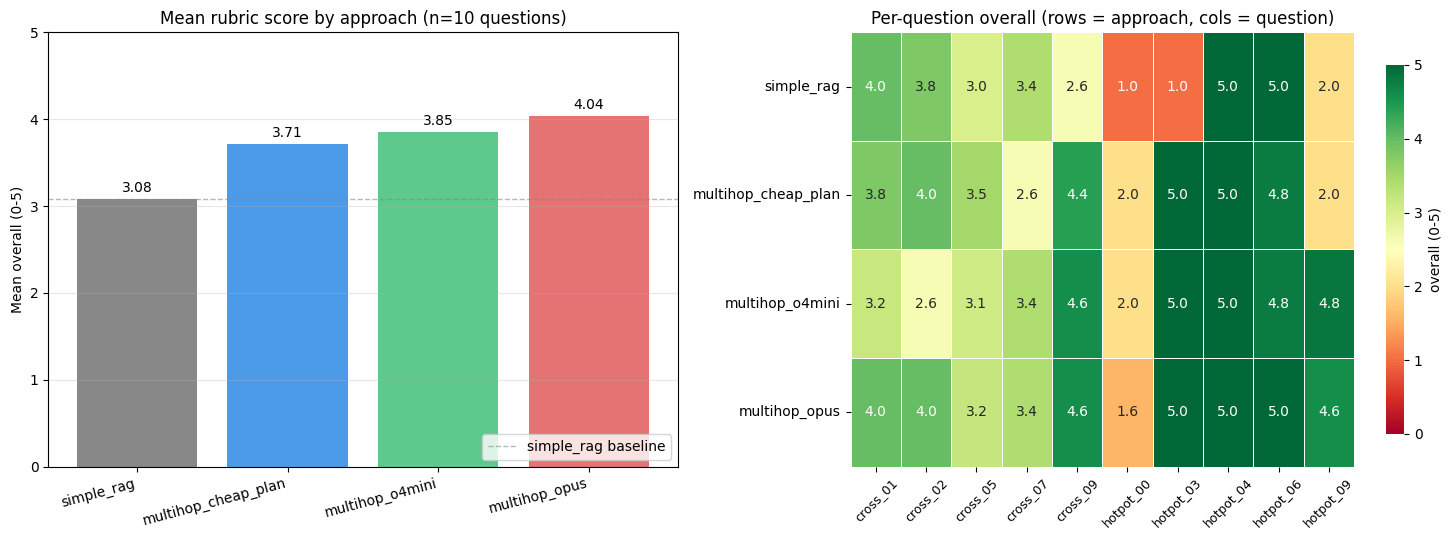

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

APPROACH_ORDER = [a for a, _ in APPROACHES]
COLORS = {
    "simple_rag":          "#888888",
    "multihop_cheap_plan": "#4c9be8",
    "multihop_o4mini":     "#5ec98c",
    "multihop_opus":       "#e57373",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

means = df.groupby("approach", sort=False)["overall"].mean().reindex(APPROACH_ORDER)
ax = axes[0]
bars = ax.bar(range(len(means)), means.values, color=[COLORS[a] for a in means.index])
ax.set_xticks(range(len(means)))
ax.set_xticklabels(means.index, rotation=15, ha="right")
ax.set_ylabel("Mean overall (0-5)")
ax.set_ylim(0, 5)
ax.set_title(f"Mean rubric score by approach (n={len(QUESTIONS_TO_RUN)} questions)")
ax.axhline(means.iloc[0], color="#888", linestyle="--", linewidth=1, alpha=0.6,
           label="simple_rag baseline")
for b, v in zip(bars, means.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.08, f"{v:.2f}", ha="center", fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(loc="lower right")

pivot = df.pivot(index="qid", columns="approach", values="overall")[APPROACH_ORDER]
sns.heatmap(
    pivot.T,
    ax=axes[1],
    cmap="RdYlGn",
    vmin=0, vmax=5,
    annot=True, fmt=".1f",
    cbar_kws={"label": "overall (0-5)", "shrink": 0.85},
    linewidths=0.4, linecolor="white",
)
axes[1].set_title("Per-question overall (rows = approach, cols = question)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45, labelsize=9)
axes[1].tick_params(axis="y", rotation=0)

fig.tight_layout()
plt.show()

### How to read the heatmap (4 column patterns)

Each column is one question; each row is one approach. The color is the rubric `overall` score (red = bad, green = good). Look for these column shapes:

- **Rescue column** — `simple_rag` (top row) is red, the three multihop rows are green. Decomposition fixed something simple RAG couldn't. *Best example: `hotpot_03`.*
- **Wasted column** — every row is red. The evidence simply isn't in the corpus, so no amount of planning helps. This is what the third notebook (better retrieval) and the fifth notebook (re-querying) attack. *Best example: `hotpot_00`.*
- **Already-solved column** — every row is green. Simple RAG nailed it; multihop is just extra latency and tokens. *Best example: `hotpot_06`.*
- **Hurt cell** — `simple_rag` is green-ish but a multihop row is *redder* than it. Decomposition scattered retrieval and made things worse. *Best example: `cross_07 × multihop_cheap_plan`.*

The takeaway isn't "multi-hop is always better" — it's "multi-hop has high variance per question, with average upside." That variance is exactly what the fifth notebook's gap-analyzer loop is designed to manage.

## Reading the table

With n=10 multi-hop questions and `gpt-5.4-nano` fixed as the synth:

| Approach | overall | Δ vs simple_rag |
|---|---:|---:|
| `simple_rag` | ~3.1 | — |
| `multihop_cheap_plan` | ~3.7 | +0.6 |
| `multihop_o4mini` | ~3.9 | +0.8 |
| `multihop_opus` | ~4.0 | +0.9 |

The architectural lift is real but modest (~+1.0 overall, ~30% relative). Smarter planners help with strong diminishing returns: going from `gpt-5.4-nano` ($0.20/M) to `claude-opus-4.7` ($15/M, 75× more expensive) buys only +0.33. **The cheap planner captures most of the workflow's value** — paying for a better planner is rarely the right place to spend.

### Per-question, four patterns show up

| Pattern | Example | Reading |
|---|---|---|
| **Decomposition rescue** | `hotpot_03`: simple=1.0 → all multihop=5.0 | 2-hop fact; simple RAG retrieved the wrong castle; any decomposition surfaces both sides. |
| **Planner-quality matters** | `hotpot_09`: cheap=2.0 vs o4-mini=4.83, opus=4.6 | Comparing two coaches needs *lateral* sub-queries; cheap planner produced junk, reasoning planners didn't. This is when paying for a better planner earns its keep. |
| **Decomposition can hurt** | `cross_07`: simple=3.4 vs cheap=2.6 | Cheap planner fanned into 4 sub-queries that scattered retrieval; weak synth got less coherent context than single dense top-k. |
| **Architecture isn't magic** | `hotpot_00`: every approach ≤ 2.0 | Answer simply isn't in our corpus. No decomposition fixes missing evidence. |
| **Best-case lift** | `cross_09`: simple=2.6, multihop≈4.5 | A +2.0 swing from decomposition alone — what you hope for. |

Decomposition is a cheap win *on average*, but variance per question is enormous: sometimes +4 (rescue), sometimes -1 (hurts), sometimes 0. The fifth notebook wraps it in a gap-analyzer loop that can re-plan when first-attempt evidence is thin. The third notebook tackles what's still missing here: dense-only retrieval (no BM25 for literal terms), no chunk grading, no second look once retrieval is done.